# **Урок 5**. Семантическая сегментация


На лекции мы с вами углубили свои знания о семантической сегментации: 
- теперь мы знаем не только ```UNet```, но и многие другие архитектуры
- знаем, что для обучения и оценки моделей можно использовать и попиксельные метрики, и метрики на множествах
- а ещё на прошлых практиках мы научились учить модели круто

Давайте сегодня возьмём тот же датасет, что уже был в базовом курсе для задачи сегментации и посмотрим, сможем ли получить на нем лучшее качество, чем раньше.

## **План**

1. Заводим базовый эксперимент с UNet
2. Учим UNet круче
3. Учим не только UNet

Брать модельки можно в [torchvision.models](https://pytorch.org/vision/stable/models.html#semantic-segmentation), но выбирать там особо не из чего. Также есть репозиторий [segmentation_models_pytorch](https://github.com/qubvel-org/segmentation_models.pytorch), где выбора явно больше, вот [табличка с архитектурами](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#architectures-).

Давайте попробуем второй вариант, так как с первым мы работать уже научились в классификации.

Устанавливаем в окружение репозиторий согласно [инструкции](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#installation).

In [ ]:
# %pip install segmentation-models-pytorch

In [ ]:
# ставим совместимую версию huggingface
# %pip install huggingface_hub==0.24.6

In [ ]:
# ставим либу для аугментаций, если её нет
#%pip install -U albumentations

## **1. Заводим базовый эксперимент с UNet**

Вспомним, что уже было. 

В качестве датасета у нас был [```NYUv2```](https://paperswithcode.com/dataset/nyuv2) - сет с различными indoor фото. В качестве модели использовали ```UNet```, оптимизировали попиксельную кросс-энтропию, а в качестве метрики качества была ```Pixel Accuracy (PA)``` — просто попиксельная точность. 

Обучая ```UNet```, получили финальную метрику на валидации ```PA = ~34%```. 
Вот эти результаты и будем сегодня бить :)


Скачайте снова датасет по прямой ссылке, если у вас его под рукой нет:

In [ ]:
#! wget http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat

In [1]:
import os
import h5py
import tqdm
import wandb
import torch
import random

import numpy as np
import typing as tp
import torch.nn as nn
import matplotlib.pyplot as plt

import segmentation_models_pytorch as smp

from functools import reduce
from torch import optim
from torch.optim import Adam
from dataclasses import dataclass
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

device = 'cuda:1'

In [2]:
# прощаемся с рандомом
# тут всю фиксацию внесла в одну функцию, чтобы поменьше функций звать
def fix_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.cuda.empty_cache()

    
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    
# сразу фиксирую сиды, чтобы разделение выборки воспроизводимо было 
fix_everything(24)

Сделаем препроцессинг датасета, который вы уже тоже видели:

In [3]:
# Напоминание про h5py: https://docs.h5py.org/en/stable/quick.html#quick
data = h5py.File('nyu_depth_v2_labeled.mat')

print(data.keys())
print(data['images'])
print(data['labels'])

<KeysViewHDF5 ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']>
<HDF5 dataset "images": shape (1449, 3, 640, 480), type "|u1">
<HDF5 dataset "labels": shape (1449, 640, 480), type "<u2">


In [4]:
# Преобразуем в numpy-массив
raw_images, raw_labels = data['images'], data['labels']
all_imgs_np, all_labels_np = np.empty_like(raw_images), np.empty_like(raw_labels)
raw_images.read_direct(all_imgs_np)
raw_labels.read_direct(all_labels_np)

In [5]:
# функция для визуализации
def show_sample(img_np, label_np):
    _, ax = plt.subplots(1, 2, figsize=(10, 8))
    ax[0].imshow(img_np)
    ax[1].imshow(label_np)
    plt.show()

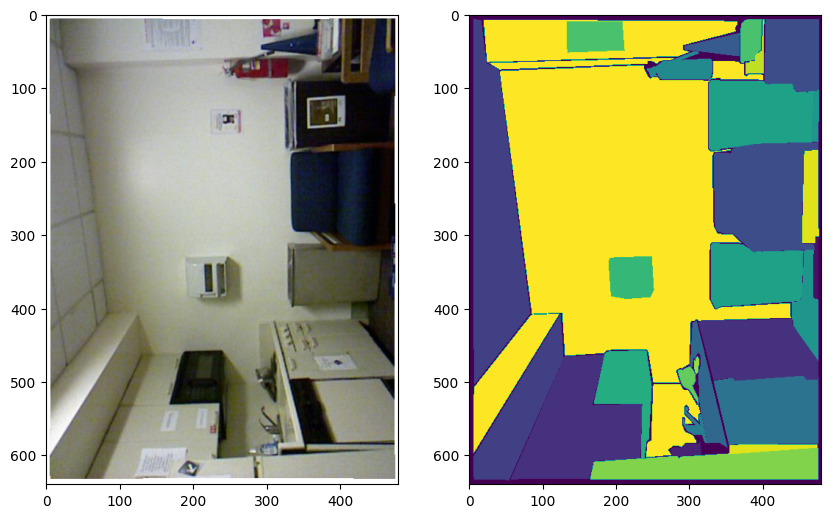

In [6]:
# Смотрим картинку и её маски
show_sample(all_imgs_np[0].transpose((1, 2, 0)), all_labels_np[0])

Из чего при этом у нас состоит маска:

In [7]:
print(all_imgs_np[0].shape)
print(all_labels_np[0].shape)
print(np.unique(all_labels_np[0]))

(3, 640, 480)
(640, 480)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


Как видим, это одноканальный массив того же размера с целыми числами — метками классов на маске. А всего классов 895.

Теперь для этих данных заведём датасет (пока такой же, как и раньше):

In [8]:
class SegmentationDataset(Dataset):
    def __init__(self, img_array, label_array, transforms):
        
        label_array = label_array.astype('int32')
        self.img_array = img_array.transpose((0, 2, 3, 1))
        self.label_array = label_array
        self.transforms = transforms

    def __getitem__(self, index):
        transformed = self.transforms(
            image=self.img_array[index], 
            mask=self.label_array[index]
        )
        return transformed['image'], transformed['mask']

    def __len__(self):
        return len(self.img_array)

In [9]:
# простейший трансформ
transform = A.Compose([
    A.Resize(128, 128), 
    A.ToFloat(max_value=255), 
    ToTensorV2()])

In [10]:
# тут я не стала выделять val/test-части отдельно, а слила вместе в test
indexes_train = np.array(random.sample(range(len(all_imgs_np)), k = int(len(all_imgs_np)*0.8)))
indexes_test = np.array(list(set(range(len(all_imgs_np))) - set(indexes_train)))

In [11]:
# в соответствии с индексами делим ndarrays
train_imgs = all_imgs_np[indexes_train]
train_masks = all_labels_np[indexes_train]

test_imgs = all_imgs_np[indexes_test]
test_masks = all_labels_np[indexes_test]

In [12]:
train_dataset = SegmentationDataset(train_imgs, train_masks, transform)
test_dataset = SegmentationDataset(test_imgs, test_masks, transform)

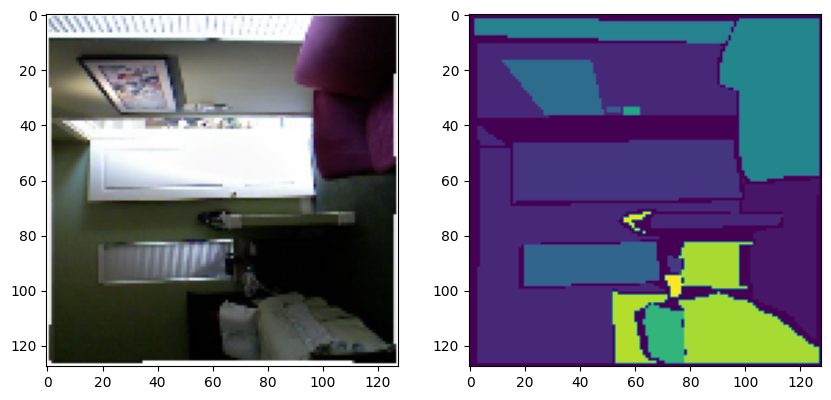

In [13]:
# проверяем, как там картинки с масками
show_sample(test_dataset[0][0].permute((1, 2, 0)), test_dataset[0][1])

In [14]:
print(train_dataset[0][0].shape)
print(train_dataset[0][1].shape)
print(np.unique(train_dataset[0][1]))

torch.Size([3, 128, 128])
torch.Size([128, 128])
[  0   2   3   7   8  11  13  16  21  22  24  26  28  35  75  88 135 141
 172 242 243 262 263 702]


In [15]:
# с этой функцией уже знакомы
def get_scheduler(config, optimizer, loader=None, step=None, gamma=None):
    if config.scheduler_type == 'exp':
        return optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    elif config.scheduler_type == 'step':
        return optim.lr_scheduler.StepLR(optimizer, step_size=step, gamma=gamma)
    elif config.scheduler_type == 'cosine':
        T_max = config.n_epochs * len(loader) 
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)
    else:
        return None

In [16]:
# функция для обучения/тестирования почти такая же, как для классификации
def run_epoch(epoch, net, loader, criterion, optimizer, scheduler, device, is_train):
    if is_train:
        net.train()
    else:
        net.eval()
        
    running_loss = 0.0
    correct = 0
    total = 0
    lr = config.lr

    for i, data in enumerate(loader):
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels.long()).mean()

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if (scheduler is not None) and (config.scheduler_type == 'cosine'):
                scheduler.step()
                lr = scheduler.get_last_lr()[0]

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1) # выбираем наиболее вероятный класс для каждого пикселя
        
        correct += (predicted == labels).sum().item() # считаем число правильных предсказаний
        total += reduce(lambda a, b: a * b, labels.shape, 1) # считаем общее число пикселей
    
    acc = correct/total
    
    print('Loss: {:.3f}, Acc: {:.3f}'.format(running_loss / (i + 1), acc * 100.0))
    
    if is_train:
        if (scheduler is not None) and (config.scheduler_type != 'cosine'): 
            scheduler.step()
            lr = scheduler.get_last_lr()[0]
        
        wandb.log({'lr': lr}, step=epoch)    
        wandb.log({'train loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'train acc': acc * 100.0}, step=epoch)
    else:
        wandb.log({'test loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'test acc': acc * 100.0}, step=epoch)

In [17]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 10
    lr: float = 1e-4
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = None

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

# и лоадеры для датасетов
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

test_loader = DataLoader(test_dataset, batch_size=config.batch_size, 
                         shuffle=False, num_workers=12, pin_memory=True)

И для начала давайте в качестве модели возьмём ```UNet``` c [энкодером](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#encoders-) ```resnet50```:

In [20]:
# дока https://smp.readthedocs.io/en/latest/models.html#id17
model = smp.Unet(
    encoder_name='resnet50',        # выбираем энкодер из доступных
    encoder_weights='imagenet',     # инициализация
    in_channels=3,                  # 1 — grayscale images, 3 — RGB
    classes=1,                    # сколько будет выходных фичемап
)

In [21]:
model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [22]:
model = model.to(device)
optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer)

In [32]:
for i, data in enumerate(train_loader):
    images, labels = data
    images, labels = images.to(device), labels.to(device)
    break

In [33]:
outputs = model(images)

In [39]:
labels[0]

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 7, 0, 0],
        ...,
        [0, 0, 4,  ..., 3, 3, 0],
        [0, 0, 4,  ..., 3, 3, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:1', dtype=torch.int32)

In [35]:
outputs.shape

torch.Size([32, 1, 128, 128])

In [21]:
wandb.init(project='lesson-5', name='unet_resnet50')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: belnasty24 (belnasty24-karpov-courses). Use `wandb login --relogin` to force relogin


Training epoch:  1 / 10
Loss: 6.603, Acc: 6.883
Validation
Loss: 6.341, Acc: 20.007
----------------------
Training epoch:  2 / 10
Loss: 6.150, Acc: 28.037
Validation
Loss: 5.795, Acc: 33.859
----------------------
Training epoch:  3 / 10
Loss: 5.670, Acc: 37.088
Validation
Loss: 5.401, Acc: 37.498
----------------------
Training epoch:  4 / 10
Loss: 5.196, Acc: 40.285
Validation
Loss: 4.963, Acc: 38.039
----------------------
Training epoch:  5 / 10
Loss: 4.759, Acc: 41.157
Validation
Loss: 4.620, Acc: 38.618
----------------------
Training epoch:  6 / 10
Loss: 4.359, Acc: 41.589
Validation
Loss: 4.279, Acc: 39.286
----------------------
Training epoch:  7 / 10
Loss: 4.001, Acc: 41.925
Validation
Loss: 3.984, Acc: 39.749
----------------------
Training epoch:  8 / 10
Loss: 3.689, Acc: 42.236
Validation
Loss: 3.669, Acc: 39.980
----------------------
Training epoch:  9 / 10
Loss: 3.411, Acc: 42.554
Validation
Loss: 3.495, Acc: 40.152
----------------------
Training epoch:  10 / 10
Loss

lr,▁▁▁▁▁▁▁▁▁▁
test acc,▁▆▇▇▇▇████
test loss,█▇▆▅▄▃▃▂▂▁
train acc,▁▅▇▇██████
train loss,█▇▆▅▄▃▃▂▁▁
lr,0.0001
test acc,40.83812
test loss,3.24335
train acc,42.85848
train loss,3.17779


Обучение выглядит стабильно, на тесте мы получили ```PA ~ 40%```, что уже на `6 п.п.` больше, чем было в базовом курсе (у нас тут всё-таки энкодер обученный уже, ещё и `resnet50`!) 

Воодушевлённые успехом, давайте посмотрим на визуализацию инференса на тесте:

In [22]:
@torch.inference_mode()
def visualize(model, batch, device):
    model.eval()
    xs, ys = batch
    xs, ys = xs[:3], ys[:3]
    for i, (x, y) in enumerate(zip(xs, ys)):
        prediction = model(x[None, ...].to(device)).cpu().squeeze(0).max(dim=0)[1]

        fig, ax = plt.subplots(1, 3, figsize=(24, 8), facecolor="white")

        ax[0].imshow(x.permute((1, 2, 0)))
        ax[1].imshow(y.to(torch.uint8))
        ax[2].imshow(prediction.to(torch.uint8))

        ax[0].axis("off")
        ax[1].axis("off")
        ax[2].axis("off")
        plt.subplots_adjust(wspace=0, hspace=0.1)
        plt.show()

        if i >= 9:
            break

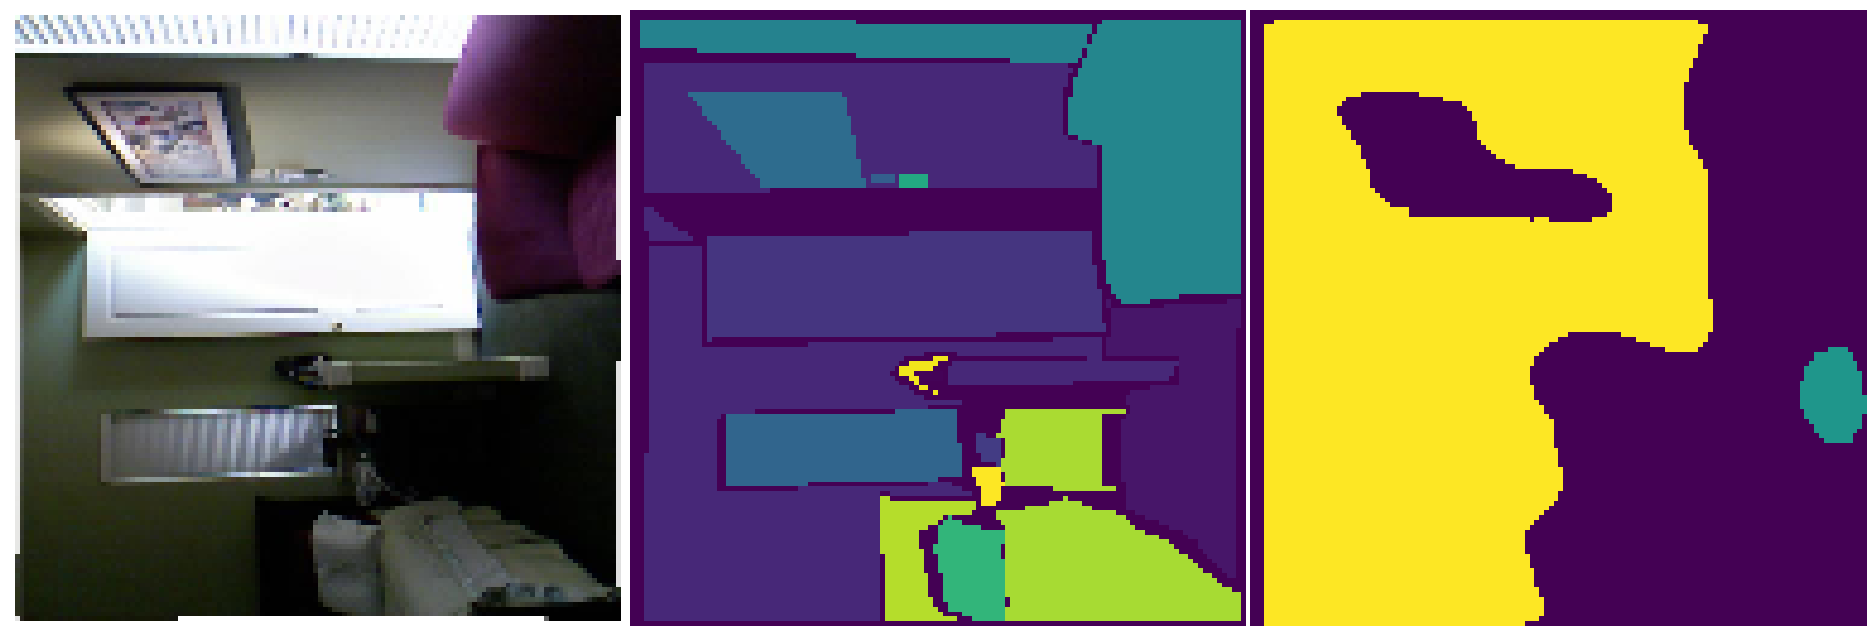

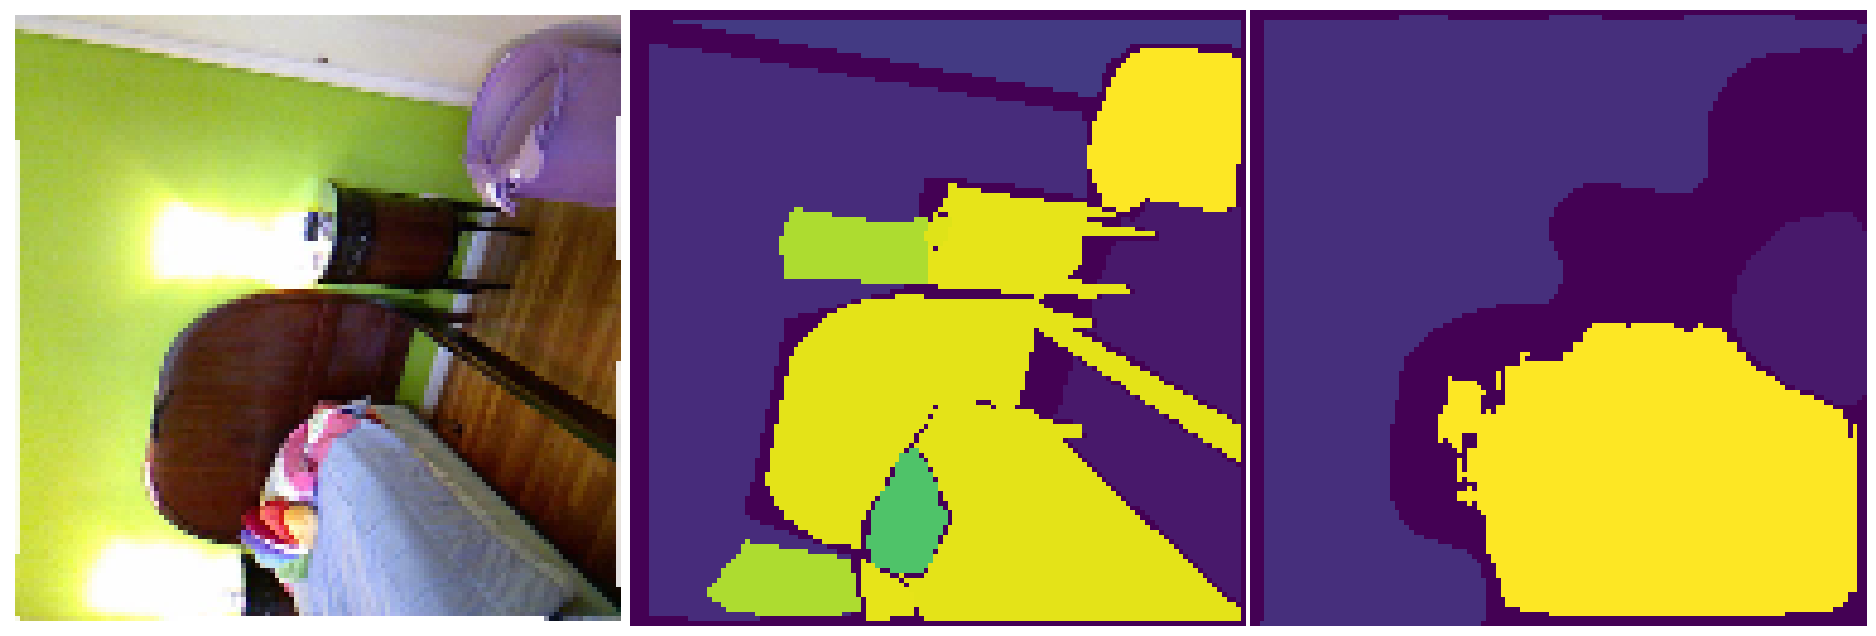

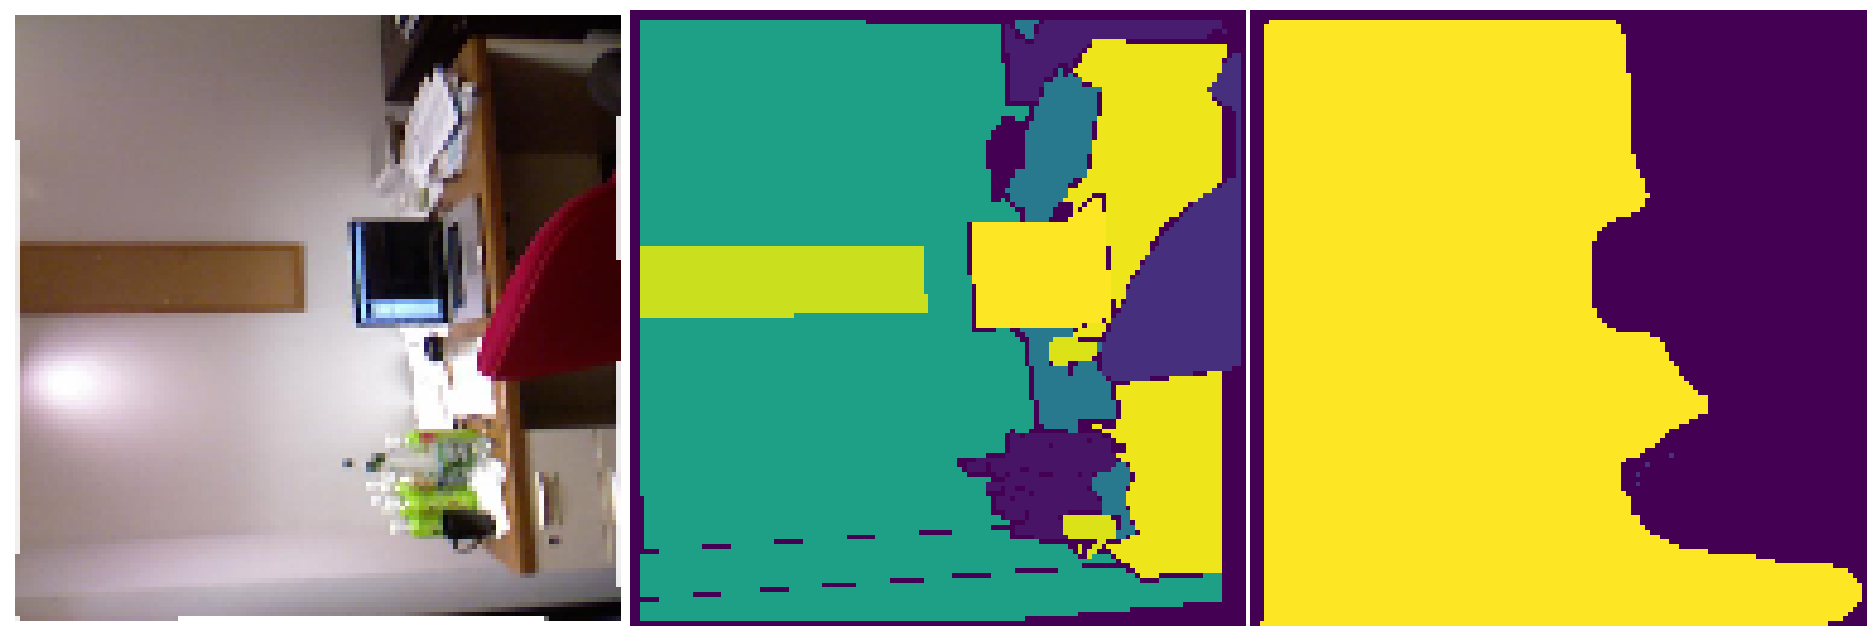

In [23]:
batch = next(iter(test_loader))
visualize(model, batch, device=device)

Выглядит, на мой взгляд, не очень воодушевляюще. 

Модель как-то очень примерно угадывает, только самые крупные объекты в кадре — отсюда и `PA` неплохая, пикселей-то таких много, однако абсолютное большинство классов она не понимает.

В общем, явно есть куда расти, этим и займёмся.

## **2. Учим UNet круче**

Какие первые идеи приходят в голову:

- судя по графикам, модель ещё активно учится, `10` эпох ей маловато, надо увеличить
- можно попробовать другие варианты претрейна и энкодера
- мы же умеем настраивать `lr`, может, ему не хватает расписания

Пойдём по порядку. Сперва учим дольше, попробуем в `1,5` раза обучение удлиннить:

In [24]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15 # изменили только число эпох
    lr: float = 1e-4
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = None

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [25]:
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer)

In [26]:
wandb.init(project='lesson-5', name='unet_resnet50_15ep')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 6.603, Acc: 6.883
Validation
Loss: 6.341, Acc: 20.007
----------------------
Training epoch:  2 / 15
Loss: 6.150, Acc: 28.037
Validation
Loss: 5.795, Acc: 33.859
----------------------
Training epoch:  3 / 15
Loss: 5.670, Acc: 37.088
Validation
Loss: 5.401, Acc: 37.498
----------------------
Training epoch:  4 / 15
Loss: 5.196, Acc: 40.285
Validation
Loss: 4.963, Acc: 38.039
----------------------
Training epoch:  5 / 15
Loss: 4.759, Acc: 41.157
Validation
Loss: 4.620, Acc: 38.618
----------------------
Training epoch:  6 / 15
Loss: 4.359, Acc: 41.589
Validation
Loss: 4.279, Acc: 39.286
----------------------
Training epoch:  7 / 15
Loss: 4.001, Acc: 41.925
Validation
Loss: 3.984, Acc: 39.749
----------------------
Training epoch:  8 / 15
Loss: 3.689, Acc: 42.236
Validation
Loss: 3.669, Acc: 39.980
----------------------
Training epoch:  9 / 15
Loss: 3.411, Acc: 42.554
Validation
Loss: 3.495, Acc: 40.152
----------------------
Training epoch:  10 / 15
Loss

lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test acc,▁▅▇▇▇▇▇▇███████
test loss,█▇▆▅▅▄▃▃▂▂▂▂▁▁▁
train acc,▁▅▇▇▇▇█████████
train loss,█▇▆▆▅▄▄▃▃▂▂▂▁▁▁
lr,0.0001
test acc,41.68204
test loss,2.74342
train acc,44.29462
train loss,2.46641


Окей, стало чуть получше — на `1.2%`. Судя по графикам обучения, модель выходит на плато, а нам бы хотелось побольше прирост увидеть — значит, надо дать ей буст.

Перенесём сюда наши знания из классификации и попробуем использовать `cosine`-шедулер на `lr`, а сам `lr` значительно увеличим - прям в `10` раз. 

In [27]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 128
    n_epochs: int = 15
    lr: float = 1e-3 # увеличили
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine' # а тут выбрали шедулер

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [28]:
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [29]:
wandb.init(project='lesson-5', name='unet_resnet50_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 4.985, Acc: 26.450
Validation
Loss: 3.445, Acc: 36.741
----------------------
Training epoch:  2 / 15
Loss: 2.926, Acc: 37.343
Validation
Loss: 2.755, Acc: 39.087
----------------------
Training epoch:  3 / 15
Loss: 2.624, Acc: 38.657
Validation
Loss: 2.629, Acc: 39.377
----------------------
Training epoch:  4 / 15
Loss: 2.503, Acc: 40.674
Validation
Loss: 2.567, Acc: 40.430
----------------------
Training epoch:  5 / 15
Loss: 2.386, Acc: 43.044
Validation
Loss: 2.435, Acc: 43.601
----------------------
Training epoch:  6 / 15
Loss: 2.278, Acc: 45.563
Validation
Loss: 2.381, Acc: 44.416
----------------------
Training epoch:  7 / 15
Loss: 2.170, Acc: 47.542
Validation
Loss: 2.290, Acc: 46.015
----------------------
Training epoch:  8 / 15
Loss: 2.081, Acc: 48.963
Validation
Loss: 2.220, Acc: 47.570
----------------------
Training epoch:  9 / 15
Loss: 1.987, Acc: 51.087
Validation
Loss: 2.187, Acc: 47.954
----------------------
Training epoch:  10 / 15
Los

lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test acc,▁▂▂▃▅▅▆▇▇▇█████
test loss,█▄▄▃▃▂▂▂▁▁▁▁▁▁▁
train acc,▁▃▄▄▅▅▆▆▆▇▇████
train loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁
lr,0.0
test acc,50.04007
test loss,2.11039
train acc,58.82193
train loss,1.69185


Вот это да, почти до `50%` добрались. Да и график обучения стал значимо другим — он сразу довольно сильно падает и мы видим с самого начала результаты выше.

А было бы так же хорошо, если бы только большой `lr` использовали, без косинуса?

In [30]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = None

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

In [31]:
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [32]:
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [33]:
wandb.init(project='lesson-5', name='unet_resnet50_15ep_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 4.983, Acc: 26.622
Validation
Loss: 3.483, Acc: 36.231
----------------------
Training epoch:  2 / 15
Loss: 2.927, Acc: 37.287
Validation
Loss: 2.806, Acc: 37.941
----------------------
Training epoch:  3 / 15
Loss: 2.626, Acc: 38.534
Validation
Loss: 3.043, Acc: 36.896
----------------------
Training epoch:  4 / 15
Loss: 2.499, Acc: 40.171
Validation
Loss: 2.505, Acc: 42.005
----------------------
Training epoch:  5 / 15
Loss: 2.380, Acc: 43.020
Validation
Loss: 2.532, Acc: 39.856
----------------------
Training epoch:  6 / 15
Loss: 2.286, Acc: 45.174
Validation
Loss: 2.416, Acc: 43.757
----------------------
Training epoch:  7 / 15
Loss: 2.188, Acc: 47.049
Validation
Loss: 2.387, Acc: 43.684
----------------------
Training epoch:  8 / 15
Loss: 2.102, Acc: 48.952
Validation
Loss: 2.295, Acc: 46.599
----------------------
Training epoch:  9 / 15
Loss: 2.009, Acc: 50.953
Validation
Loss: 2.256, Acc: 46.928
----------------------
Training epoch:  10 / 15
Los

lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test acc,▁▂▁▄▃▅▅▆▇▇▄█▇█▇
test loss,█▄▆▃▃▂▂▂▂▁▃▁▁▁▂
train acc,▁▃▄▄▅▅▅▆▆▇▇▇▇██
train loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁
lr,0.001
test acc,48.18357
test loss,2.24261
train acc,58.87538
train loss,1.62354


Результат тоже хороший — мы видим не такой провал, как в классификации с большим `lr` без снижения, а в начале обучения графики вообще совпадают. Но финально результат всё же хуже чем с косинусом, при этом он заметно менее стабильный — провалился в самом конце почти на `1 п.п.`.

Тогда давайте зафиксируем стратегию `cosine` + `lr=1e3` и попробуем взять для `UNet` другой энкодер (а декодер останется таким же), ведь на `Resnet`-ах свет клином не сошёлся. 

Посмотрим, какие модели у нас есть в [репозитории](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#-models-). Так как я лично очень люблю `efficientnet-b4`, давайте попробуем её:

In [34]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

In [35]:
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [36]:
model = smp.Unet(encoder_name='efficientnet-b4', encoder_weights='imagenet', in_channels=3, classes=895) # заменили энкодер
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [37]:
wandb.init(project='lesson-5', name='unet_efficientnet-b4_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 5.003, Acc: 22.644
Validation
Loss: 3.333, Acc: 26.542
----------------------
Training epoch:  2 / 15
Loss: 2.989, Acc: 32.827
Validation
Loss: 2.928, Acc: 34.982
----------------------
Training epoch:  3 / 15
Loss: 2.592, Acc: 39.488
Validation
Loss: 2.693, Acc: 39.408
----------------------
Training epoch:  4 / 15
Loss: 2.409, Acc: 42.023
Validation
Loss: 2.610, Acc: 41.110
----------------------
Training epoch:  5 / 15
Loss: 2.281, Acc: 44.466
Validation
Loss: 2.486, Acc: 42.882
----------------------
Training epoch:  6 / 15
Loss: 2.150, Acc: 47.539
Validation
Loss: 2.428, Acc: 44.523
----------------------
Training epoch:  7 / 15
Loss: 2.032, Acc: 50.649
Validation
Loss: 2.355, Acc: 45.559
----------------------
Training epoch:  8 / 15
Loss: 1.924, Acc: 53.151
Validation
Loss: 2.283, Acc: 47.133
----------------------
Training epoch:  9 / 15
Loss: 1.831, Acc: 55.305
Validation
Loss: 2.278, Acc: 47.252
----------------------
Training epoch:  10 / 15
Los

lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test acc,▁▃▅▅▆▆▆▇▇██████
test loss,█▆▄▄▃▃▂▂▂▁▁▁▁▁▁
train acc,▁▃▄▄▅▅▆▆▇▇█████
train loss,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁
lr,0.0
test acc,51.2214
test loss,2.10766
train acc,61.50353
train loss,1.59062


Замечательно! Медленно, но верно, мы растём и снова поднялись на `1 п.п.` — теперь перевалили за `51%`.

Подведём небольшие итоги:
- учить дольше круче (снова)
- использовать `cosine` с большим `lr` круче (снова)
- `EfficientNet` показывает лучше результаты, чем `ResNet` (снова)

Пока все наши знания успешно переносятся с классификации на сегментацию, даже скучно.

Давайте разнообразим нашу жизнь и попробуем отойти от архитектуры `UNet`.

## **3. Учим не только UNet**

Сперва сильно далеко уходить не будем и попробуем `UNet++` — вариант сети с более сложным декодером.

<p align="center">
  <a href="images/unet_plus.png"><img src="images/unet_plus.png" style="width:50%;"/></a>
</p>

In [38]:
# тут ничего не трогаем
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [39]:
# а вот тут у нас будет Unet++, а не UNet, подменяется влёгкую
# дока https://smp.readthedocs.io/en/latest/models.html#unetplusplus
model = smp.UnetPlusPlus(encoder_name='efficientnet-b4', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [40]:
wandb.init(project='lesson-5', name='unet++_efficientnet-b4_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 4.977, Acc: 23.173
Validation
Loss: 3.293, Acc: 30.075
----------------------
Training epoch:  2 / 15
Loss: 2.929, Acc: 35.056
Validation
Loss: 2.915, Acc: 35.688
----------------------
Training epoch:  3 / 15
Loss: 2.541, Acc: 39.892
Validation
Loss: 2.647, Acc: 40.335
----------------------
Training epoch:  4 / 15
Loss: 2.347, Acc: 43.761
Validation
Loss: 2.563, Acc: 41.735
----------------------
Training epoch:  5 / 15
Loss: 2.188, Acc: 46.677
Validation
Loss: 2.557, Acc: 41.127
----------------------
Training epoch:  6 / 15
Loss: 2.050, Acc: 49.587
Validation
Loss: 2.410, Acc: 45.225
----------------------
Training epoch:  7 / 15
Loss: 1.935, Acc: 52.218
Validation
Loss: 2.344, Acc: 46.583
----------------------
Training epoch:  8 / 15
Loss: 1.827, Acc: 54.892
Validation
Loss: 2.296, Acc: 46.341
----------------------
Training epoch:  9 / 15
Loss: 1.734, Acc: 57.257
Validation
Loss: 2.219, Acc: 48.379
----------------------
Training epoch:  10 / 15
Los

lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test acc,▁▃▄▅▅▆▆▆▇▇█████
test loss,█▆▄▄▄▃▃▂▂▂▁▁▁▁▁
train acc,▁▃▄▅▅▆▆▇▇▇█████
train loss,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁
lr,0.0
test acc,51.9988
test loss,2.0401
train acc,63.25974
train loss,1.4948


Класс, поднялись на `1 п.п.` относительно базовой `UNet`, уже чувствуем себя великими.

Теперь давайте попробуем признаки с разных уровней переагрегировать — использовать `Feature Pyramod Network (FPN)`.

Вот так она выглядит по сравнению с `UNet`:

<p align="center">
  <a href="images/fpn.png"><img src="images/fpn.png" style="width:80%; height:50%;"/></a>
</p>

In [41]:
# тут ничего не трогаем
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [42]:
# а вот тут у нас будет FPN, а не UNet
# дока https://smp.readthedocs.io/en/latest/models.html#fpn
model = smp.FPN(encoder_name='efficientnet-b4', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [43]:
wandb.init(project='lesson-5', name='fpn_efficientnet-b4_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 3.183, Acc: 37.506
Validation
Loss: 2.493, Acc: 43.774
----------------------
Training epoch:  2 / 15
Loss: 2.162, Acc: 50.040
Validation
Loss: 2.271, Acc: 47.322
----------------------
Training epoch:  3 / 15
Loss: 1.811, Acc: 56.273
Validation
Loss: 2.209, Acc: 48.576
----------------------
Training epoch:  4 / 15
Loss: 1.564, Acc: 61.306
Validation
Loss: 2.164, Acc: 49.899
----------------------
Training epoch:  5 / 15
Loss: 1.382, Acc: 65.139
Validation
Loss: 2.091, Acc: 51.886
----------------------
Training epoch:  6 / 15
Loss: 1.229, Acc: 68.219
Validation
Loss: 2.005, Acc: 53.088
----------------------
Training epoch:  7 / 15
Loss: 1.125, Acc: 70.527
Validation
Loss: 1.962, Acc: 54.529
----------------------
Training epoch:  8 / 15
Loss: 1.031, Acc: 72.559
Validation
Loss: 1.874, Acc: 55.236
----------------------
Training epoch:  9 / 15
Loss: 0.959, Acc: 74.038
Validation
Loss: 1.858, Acc: 55.864
----------------------
Training epoch:  10 / 15
Los

lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test acc,▁▃▃▄▅▆▆▇▇▇█████
test loss,█▆▅▅▄▃▃▂▂▂▁▁▁▁▁
train acc,▁▃▄▅▆▆▇▇▇██████
train loss,█▅▄▃▃▂▂▂▁▁▁▁▁▁▁
lr,0.0
test acc,57.90157
test loss,1.76413
train acc,77.54487
train loss,0.803


Ну всё, ракета нашего обучения полетела в космос. Надеюсь, после этого вы оценили всю мощь агрегации признаков, ведь мы почти до `58%` дошли!

Давайте ещё проверим будет ли разница между различной реализацией мерджа признаков при их агрегации в декодере `FPN` - через сложение или конкатенацию. 

In [44]:
# тут ничего не трогаем
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [45]:
# изменим только decoder_merge_policy
# дока https://smp.readthedocs.io/en/latest/models.html#fpn
model = smp.FPN(encoder_name='efficientnet-b4', encoder_weights='imagenet', decoder_merge_policy='cat', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [46]:
wandb.init(project='lesson-5', name='fpn_cat_efficientnet-b4_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 3.044, Acc: 37.895
Validation
Loss: 2.533, Acc: 41.600
----------------------
Training epoch:  2 / 15
Loss: 2.106, Acc: 50.392
Validation
Loss: 2.242, Acc: 46.347
----------------------
Training epoch:  3 / 15
Loss: 1.744, Acc: 57.120
Validation
Loss: 2.048, Acc: 50.204
----------------------
Training epoch:  4 / 15
Loss: 1.495, Acc: 62.274
Validation
Loss: 2.019, Acc: 51.600
----------------------
Training epoch:  5 / 15
Loss: 1.293, Acc: 66.574
Validation
Loss: 2.000, Acc: 52.305
----------------------
Training epoch:  6 / 15
Loss: 1.140, Acc: 69.863
Validation
Loss: 1.924, Acc: 53.864
----------------------
Training epoch:  7 / 15
Loss: 1.021, Acc: 72.453
Validation
Loss: 1.892, Acc: 54.767
----------------------
Training epoch:  8 / 15
Loss: 0.925, Acc: 74.603
Validation
Loss: 1.844, Acc: 55.495
----------------------
Training epoch:  9 / 15
Loss: 0.852, Acc: 76.265
Validation
Loss: 1.818, Acc: 56.191
----------------------
Training epoch:  10 / 15
Los

lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test acc,▁▃▅▅▅▆▆▇▇▇█████
test loss,█▆▄▄▃▃▃▂▂▂▁▁▁▁▁
train acc,▁▃▄▅▆▆▇▇▇██████
train loss,█▅▄▃▃▂▂▂▁▁▁▁▁▁▁
lr,0.0
test acc,58.37895
test loss,1.71343
train acc,79.76424
train loss,0.70115


Как видим, конкатенация, а не складывание признаков, даёт ещё чуть лучший результат — но и учились мы подольше, так как обрабатывать надо большее число фичей. Зато `58.2%` точности получили, ай да мы.

В целом по сравнению с классификацией метрики здесь далеко не так высоки. Но это нормально, сегментация как задача, и конкретно этот датасет очень сложны. Неудивительно, что мы за 5-10 минут обучения не получаем на нём `SOTA`-результаты.

Давайте посмотрим, будет ли визуально заметно, как мы выросли с `40%` до `58%` точности:

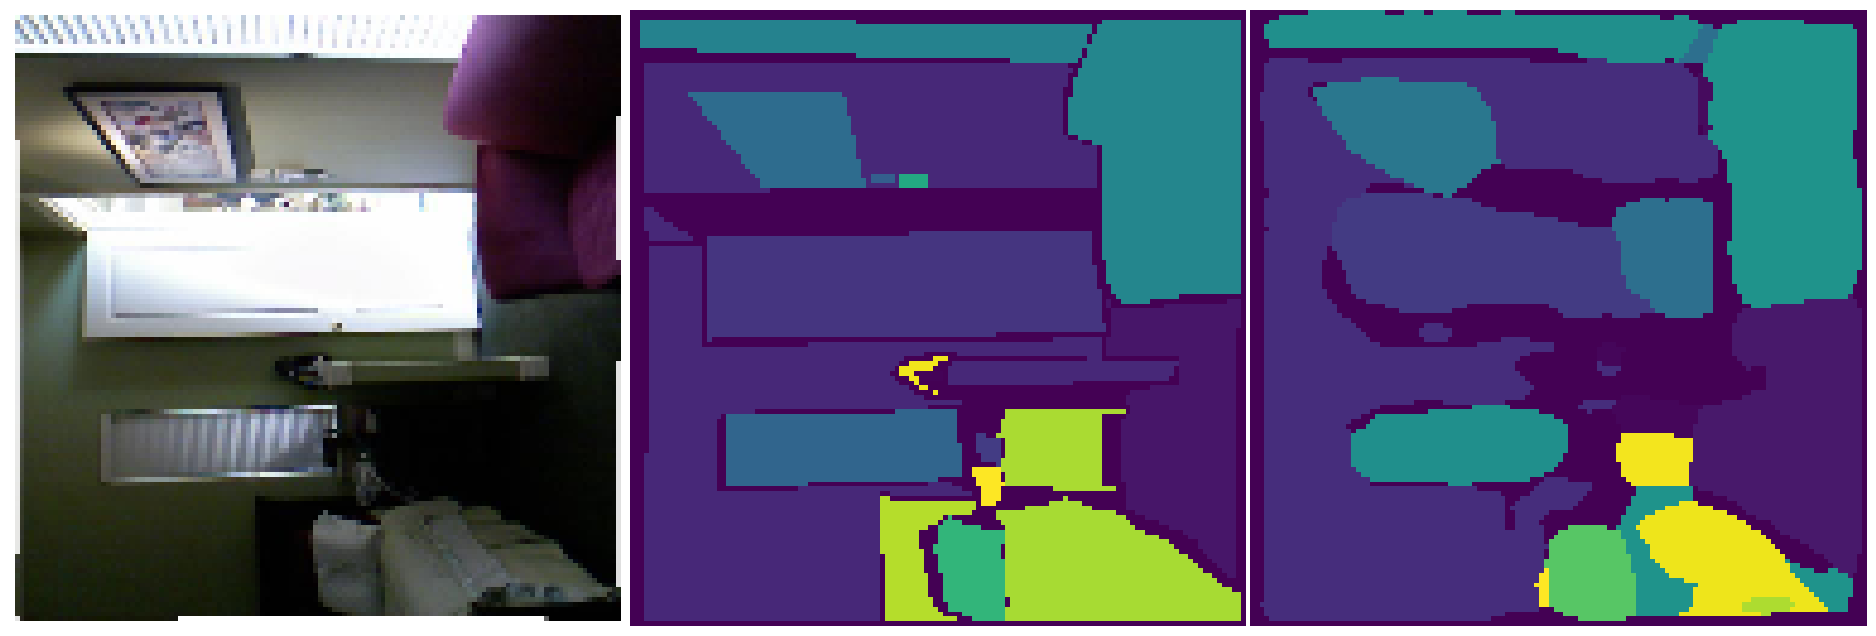

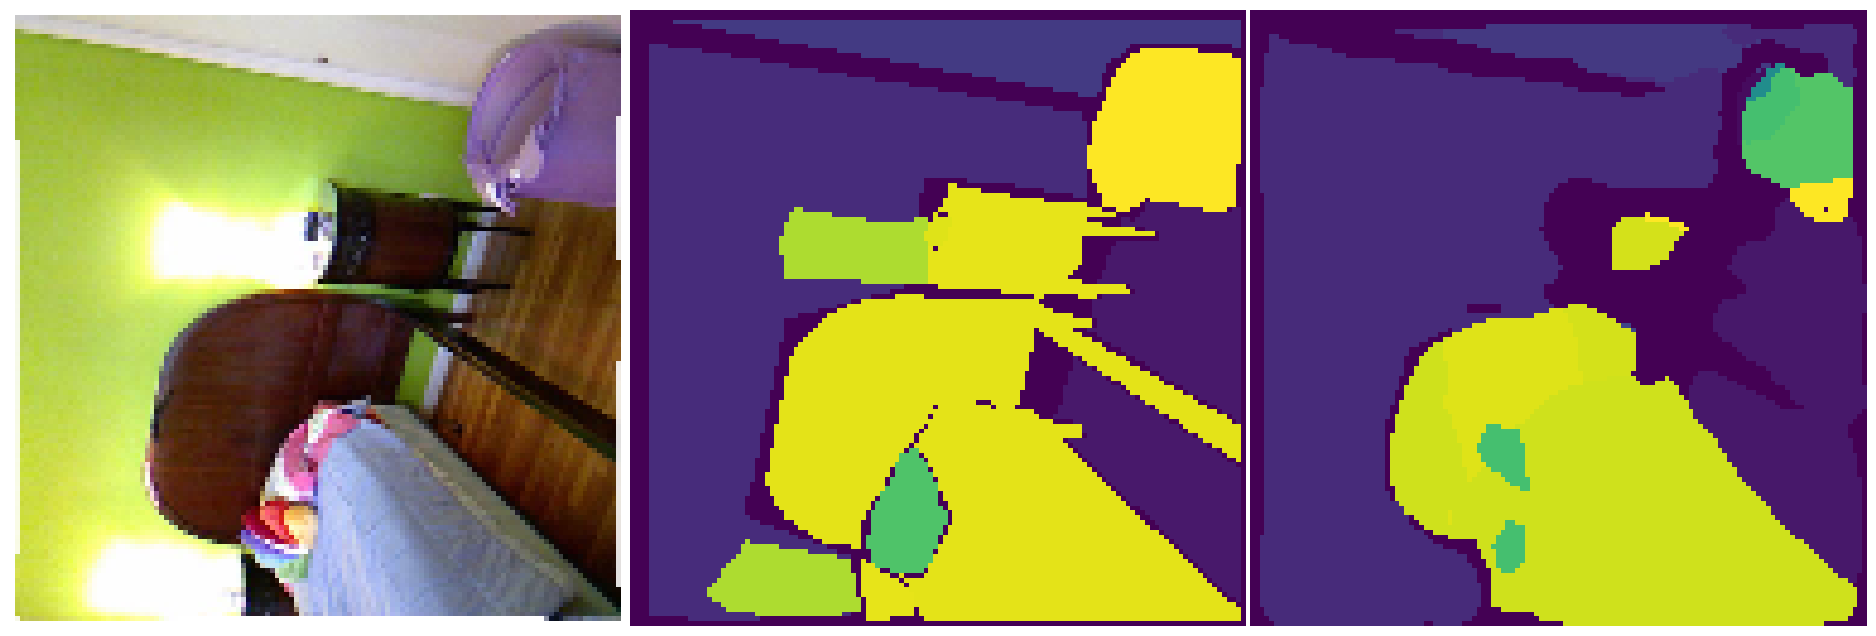

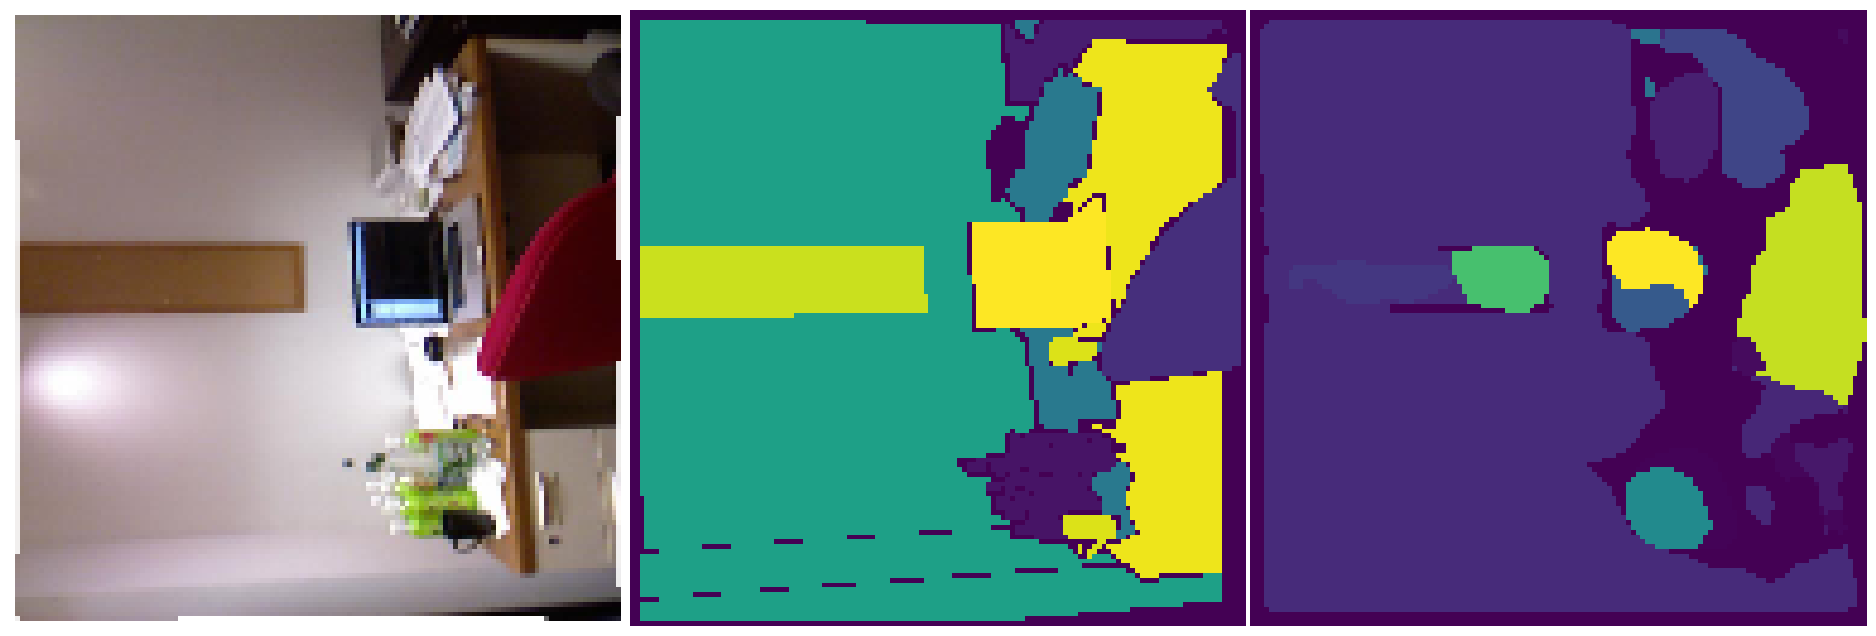

In [47]:
batch = next(iter(test_loader))
visualize(model, batch, device=device)

В целом, да, на первых двух картинках пятна классов лучше оформились :)

Итак,
- `UNet++` c более мощным декодером ещё чуть накидывает точности сегментации
- `FPN` даёт огромный прирост качества 
- причём использовать `concat` признаков в пирамиде будет чуть эффективнее
- не забываем при этом, что `FPN` тяжелее `UNet` и будет работать подольше

Зато мы можем очень сильно порадоваться точности её работы, этим и занимаемся, пока подводим итоги.

## **Итоги**

В этой практике мы:

- провели эксперимент на `NYUv2` без самописного `UNet`-а
- перенесли некоторые свои знания из эффективного обучения моделей классификации на сегментацию и получили улучшения!
- протестировали разные бэкбоны для `UNet`-а, и снова увидели, что `EfficientNet` — супер
- кроме `UNet`, провели эксперименты с `FPN` и оценили, как мощна агрегация признаков

При этом мы много чего не успели попробовать - например, варьировать аугментации данных, использовать лоссы на множествах и комбинировать разные их типы. И у тебя будет классная возможность погрузиться в эти вопросы в ДЗ. 

Ну а мы продолжим практику работой с суперской фундаментальной моделью — `Segment Anything (SAM)`.